# Kapitel 5 — Finale Auswertung (alle Abbildungen und Kennzahlen)

Ein Notebook für die komplette quantitative Evidenz von Kapitel 5: Modellauswahl (5.6), Ground-Truth-Vergleich (5.7) und MQA-Vergleich (5.8). Konsolidiert die Notebooks 14/15 (Modellauswahl + Reproduzierbarkeit), 16 (Ground Truth) und 17 (MQA) zu einer einzigen, durchgängigen Quelle.

**Keine Rescoring-Option.** Dieses Notebook liest ausschließlich bereits abgeschlossene Läufe unter `outputs/runs/` sowie zwei gecachte MQA-Metriken-CSVs — es ruft nie ein LLM auf und stellt keine `RECOMPUTE`/`USE_LLM`-Schalter bereit. Insgesamt **8 Datenquellen**:

| Rolle | Modell | Läufe |
|---|---|---|
| Modellauswahl + Reproduzierbarkeit (5.6), Kernstichprobe n=50→30 | GPT-5.5 | 3 Wiederholungen |
| Modellauswahl + Reproduzierbarkeit (5.6), Kernstichprobe n=50→30 | Sonnet 4.6 | 3 Wiederholungen |
| Modellauswahl (5.6), Kernstichprobe n=50 | Opus 4.8 | 1 Lauf |
| Ground Truth + MQA (5.7/5.8), Extremfälle n=20 | GPT-5.5 | 1 Lauf |

Der erste der drei GPT-5.5-Läufe ist **derselbe Lauf**, der auch als finale Kernstichprobe für 5.7.1/5.8.1 dient (ein Lauf, drei Rollen: Modellvergleichs-Einzelpunkt, erste Wiederholung, GT-/MQA-Referenz) — konsistent mit der in 5.6.1 getroffenen Entscheidung für GPT-5.5.

In [1]:
# ---------------------------------------------------------------------------
# EINGABE -- alle 8 Datenquellen. Rein lesend, keine Recompute-Option.
# ---------------------------------------------------------------------------

# ---- 5.6 Modellauswahl + Reproduzierbarkeit: 7 Läufe auf der Kernstichprobe ----
RUN_GPT55 = [
    "outputs/runs/run_2026-07-16_11-10-53_state-evaluation-final_EVAL_gpt5-5",  # = KERN_RUN (5.7/5.8)
    "outputs/runs/run_2026-07-20_11-43-12_state-evaluation-final_EVAL_gpt5-5",
    "outputs/runs/run_2026-07-20_11-55-49_state-evaluation-final_EVAL_gpt5-5",
]
RUN_SONNET46 = [
    "outputs/runs/run_2026-07-16_13-23-41_state-evaluation-final_EVAL_sonnet4-6",
    "outputs/runs/run_2026-07-20_08-41-30_state-evaluation-final_EVAL_sonnet4-6",
    "outputs/runs/run_2026-07-20_09-01-17_state-evaluation-final_EVAL_sonnet4-6",
]
RUN_OPUS48 = [
    "outputs/runs/run_2026-07-16_11-51-42_state-evaluation-final_EVAL_opus4-8",
]
MODELL_RUNS = {"GPT-5.5": RUN_GPT55, "Sonnet 4.6": RUN_SONNET46, "Opus 4.8": RUN_OPUS48}

# Gemeinsame Teilstichprobe aller Wiederholungslaeufe (die 50-Datei-Laeufe
# werden automatisch auf denselben Teilsatz reduziert).
DATEI_FILTER_N30 = r"_0[234]\.rdf$"

# ---- 5.7 + 5.8 Ground Truth / MQA: die zwei finalen Laeufe ----
KERN_RUN = RUN_GPT55[0]
EXTREM_RUN = "outputs/runs/run_2026-07-22_09-23-07_state-evaluation-final_EVAL"

KERN_GT = "data/sample_2026-06-25_09-57/ground_truth_template_slim.csv"
EXTREM_GT = "data/extreme_cases_05/ground_truth_template_slim.csv"

# MQA-Metriken sind deterministisch/probe-basiert und vom Prototyp-Modell
# unabhaengig -- beide CSVs sind bereits fertig berechnet (inkl. Live-HTTP-Probe
# fuer die Extremfaelle) und werden hier nur gelesen, nie neu geprobt.
KERN_MQA_CACHE = "outputs/mqa_comparison/comparison_sample_2026-06-25_09-57_20260720_103043/mqa_metrics.csv"
EXTREM_MQA_CACHE = "outputs/mqa_comparison/comparison_extreme_cases_05_gpt5-5_final/mqa_metrics.csv"

AUSGABE_ORDNER = "thesis/images"
KENNZAHLEN_EXPORT = "outputs/thesis_kennzahlen_final.json"

In [2]:
import json
import re
import statistics as st
import sys
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

%matplotlib inline

REPO_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(REPO_ROOT / "src"))

from evaluation import ground_truth as gt  # noqa: E402
from evaluation import indicator_join as ij  # noqa: E402

out_dir = REPO_ROOT / AUSGABE_ORDNER
out_dir.mkdir(parents=True, exist_ok=True)

DIMS = ["findability", "accessibility", "reusability", "expressiveness"]
DIM_DE = {"findability": "Auffindbarkeit", "accessibility": "Zugänglichkeit",
          "reusability": "Wiederverwendbarkeit", "expressiveness": "Aussagekraft"}
LLM_DIM = "expressiveness"

TRI_DIM_DE = {**DIM_DE, "gesamt (4 Dim.)": "Gesamt (4 Dim.)",
              "ohne Expressiveness (3 Dim.)": "Ohne Aussagekraft (3 Dim.)"}

# ---- Stil: identisch fuer alle Abbildungen dieses Kapitels ----
FARBEN_MODELL = {"GPT-5.5": "#2a78d6", "Opus 4.8": "#008300", "Sonnet 4.6": "#e87ba4"}
HAUPT = FARBEN_MODELL["GPT-5.5"]   # Prototyp / finales Modell
CEILING = "#aec6e8"                 # helle Toenung von HAUPT
MQA = "#9aa3ad"                      # neutral/grau: Baseline
DISAGREE = "#c9503f"
VERDICT = {"gut": "#2f8f46", "mittel": "#d9a441", "schlecht": "#c9503f"}
TEXT, TEXT_SEK, GRID = "#0b0b0b", "#52514e", "#d8d7d2"


def stil(ax):
    for r in ("top", "right"):
        ax.spines[r].set_visible(False)
    for r in ("left", "bottom"):
        ax.spines[r].set_color(GRID)
    ax.tick_params(colors=TEXT_SEK, labelsize=9)


def speichern(fig, name):
    for endung in ("png", "pdf"):
        p = out_dir / f"{name}.{endung}"
        fig.savefig(p, dpi=200, bbox_inches="tight", facecolor="white", edgecolor="none")
        print(f"geschrieben: {p.relative_to(REPO_ROOT)}")


def spearman_np(x, y):
    """Spearman rho -- delegiert an evaluation.ground_truth.spearman.

    Wichtig: Bindungen muessen gemittelte Raenge erhalten. Eine Implementierung
    ueber argsort(argsort(...)) vergibt gebundenen Werten fortlaufende Raenge
    nach Zeilenreihenfolge und erfindet damit eine Rangordnung, die in den Daten
    nicht existiert. Das faellt hier stark ins Gewicht, weil gt_overall als
    Mittel aus vier ganzzahligen 0-5-Bewertungen nur Vielfache von 0,25 annimmt
    (Kernstichprobe: 9 verschiedene Werte auf 50 Datensaetze).
    """
    return gt.spearman(x, y)


def run_pfad(run) -> Path:
    p = Path(run)
    return p if p.is_absolute() else REPO_ROOT / p


KENNZAHLEN = {}  # zentrales Sammelbecken -> am Ende als eine JSON exportiert

## 5.6.1 Modellauswahl — Spearman ρ je Dimension und Kandidat (Kernstichprobe, n=50)

Je ein Lauf pro Modell (der erste Eintrag in `MODELL_RUNS`), verglichen gegen dieselbe Ground Truth. Kennzahlen werden direkt aus dem Lauf + der GT-CSV berechnet (`evaluation.ground_truth.compare`), nicht aus vorberechneten Zwischenständen.

In [3]:
def kennzahlen_einzellauf(run, gt_csv):
    """Alle Kennzahlen fuer einen einzelnen Modell-Lauf gegen die Ground Truth."""
    merged = gt.merge_scores(gt.load_ground_truth(REPO_ROOT / gt_csv),
                              gt.load_model_scores(run_pfad(run)))
    result = gt.compare(merged)
    o = result["overall"]
    per_dim = result["per_dimension"]
    conf = result["confusion"]
    cost = json.loads((run_pfad(run) / "run_cost_summary.json").read_text(encoding="utf-8"))
    return {
        "rho_dim": {d: float(per_dim.loc[d, "spearman"]) for d in DIMS},
        "rho_gesamt": float(o["spearman_overall"]),
        "mae": float(o["mae"]),
        "bias_gesamt": float(o["bias"]),
        "bias_aussagekraft": float(merged["model_expressiveness_0_5"].sub(merged["gt_expressiveness"]).mean()),
        "accuracy": float(o["accuracy"]),
        "kappa_gewichtet": float(o["weighted_kappa"]),
        "pabak": float(o["pabak"]),
        "auc_gut_vs_rest": float(o["auc_gut_vs_rest"]),
        "als_gut_erkannt": int(conf.loc["GT:gut", "M:gut"]) if "GT:gut" in conf.index else 0,
        "n_gut_gt": int(conf.loc["GT:gut"].sum()) if "GT:gut" in conf.index else 0,
        "kosten_usd": float(cost["total_cost_usd"]),
        "n_dateien": int(cost["files_processed"]),
    }


modellauswahl = {m: kennzahlen_einzellauf(runs[0], KERN_GT) for m, runs in MODELL_RUNS.items()}
KENNZAHLEN["modellauswahl"] = modellauswahl

kenn_tab = pd.DataFrame({m: {
    "rho Aussagekraft": k["rho_dim"]["expressiveness"],
    "rho gesamt": k["rho_gesamt"],
    "MAE": k["mae"],
    "Bias gesamt": k["bias_gesamt"],
    "Bias Aussagekraft": k["bias_aussagekraft"],
    "Accuracy": k["accuracy"],
    "kappa (gewichtet)": k["kappa_gewichtet"],
    "PABAK": k["pabak"],
    "AUC gut-vs-rest": k["auc_gut_vs_rest"],
    "als gut erkannt": f"{k['als_gut_erkannt']}/{k['n_gut_gt']}",
    "Kosten je 50 Datens. (USD)": k["kosten_usd"],
} for m, k in modellauswahl.items()}).T
print("Deterministische Dimensionen (identisch über alle Modelle):")
for d in DIMS[:3]:
    print(f"  {DIM_DE[d]:<22} rho = {modellauswahl['GPT-5.5']['rho_dim'][d]:.4f}")
print()
kenn_tab.round(3)

loaded 50 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-16_11-10-53_state-evaluation-final_EVAL_gpt5-5


loaded 50 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-16_13-23-41_state-evaluation-final_EVAL_sonnet4-6


loaded 50 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-16_11-51-42_state-evaluation-final_EVAL_opus4-8


Deterministische Dimensionen (identisch über alle Modelle):
  Auffindbarkeit         rho = 0.5244
  Zugänglichkeit         rho = 0.7119
  Wiederverwendbarkeit   rho = 0.7390



,rho Aussagekraft,rho gesamt,MAE,Bias gesamt,Bias Aussagekraft,Accuracy,kappa (gewichtet),PABAK,AUC gut-vs-rest,als gut erkannt,Kosten je 50 Datens. (USD)
GPT-5.5,0.568732,0.765463,0.289213,0.018016,-0.076833,0.92,0.635036,0.88,0.906667,3/5,1.790419
Sonnet 4.6,0.598068,0.744731,0.308028,-0.143609,-0.723333,0.88,0.358974,0.82,0.875556,1/5,2.021067
Opus 4.8,0.608408,0.769747,0.275359,-0.01765,-0.2195,0.9,0.507874,0.85,0.902222,2/5,4.09817


geschrieben: thesis/images/modellauswahl_rho_je_dimension.png


geschrieben: thesis/images/modellauswahl_rho_je_dimension.pdf


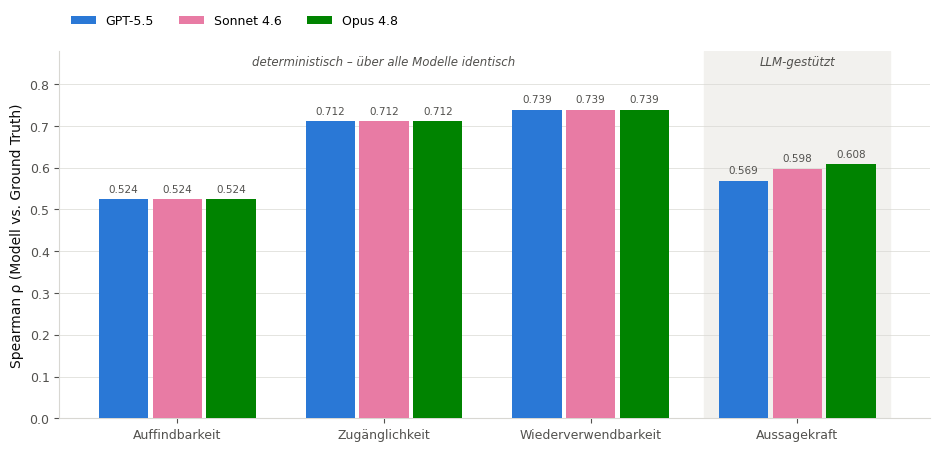

In [4]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
x, breite = np.arange(len(DIMS)), 0.26
i_llm = DIMS.index(LLM_DIM)
ax.axvspan(i_llm - 0.45, i_llm + 0.45, color="#f2f1ee", zorder=0)

for k, m in enumerate(MODELL_RUNS):
    werte = [modellauswahl[m]["rho_dim"][d] for d in DIMS]
    balken = ax.bar(x + (k - 1) * breite, werte, breite * 0.92, label=m,
                    color=FARBEN_MODELL[m], zorder=3)
    for b, w in zip(balken, werte):
        ax.text(b.get_x() + b.get_width() / 2, w + 0.012, f"{w:.3f}", ha="center",
                va="bottom", fontsize=7.5, color=TEXT_SEK, zorder=4)

ax.set_ylabel("Spearman ρ (Modell vs. Ground Truth)", fontsize=10, color=TEXT)
ax.set_ylim(0, 0.88)
ax.set_xticks(x)
ax.set_xticklabels([DIM_DE[d] for d in DIMS], fontsize=10, color=TEXT)
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="-", linewidth=0.6, color=GRID, alpha=0.8)
stil(ax)
ax.annotate("deterministisch – über alle Modelle identisch", xy=(1.0, 0.845),
            ha="center", fontsize=8.5, color=TEXT_SEK, style="italic")
ax.annotate("LLM-gestützt", xy=(i_llm, 0.845), ha="center", fontsize=8.5,
            color=TEXT_SEK, style="italic")
ax.legend(frameon=False, fontsize=9, ncol=3, loc="upper left", bbox_to_anchor=(0.0, 1.13))
fig.tight_layout()
speichern(fig, "modellauswahl_rho_je_dimension")
plt.show()

## 5.6.2 Reproduzierbarkeit — GPT-5.5 vs. Sonnet 4.6 über drei Wiederholungsläufe (n=30)

Zwei Kennzahlenarten: **(a)** externe Rangkorrelation jedes einzelnen Laufs gegen die Ground Truth (nur Aussagekraft, da einzige LLM-Dimension) — zeigt, wie stark ein Modellabstand durch Zufallsstreuung erklärbar ist; **(b)** interne Lauf-zu-Lauf-Konsistenz ohne Ground-Truth-Bezug (Spanne, Standardabweichung, paarweise MAE/ρ, Statuswechsel je Kriterium) — ein eigenständiges Gütekriterium der Pipeline.

In [5]:
muster_n30 = re.compile(DATEI_FILTER_N30)


def rho_lauf_vs_gt(run, gt_csv):
    """(a) Externe Rangkorrelation eines einzelnen Laufs gegen die GT, nur Aussagekraft."""
    df = gt.merge_scores(gt.load_ground_truth(REPO_ROOT / gt_csv), gt.load_model_scores(run_pfad(run)))
    teil = df[df["file"].astype(str).str.contains(muster_n30)]
    return float(gt.spearman(teil[f"model_{LLM_DIM}"], teil[f"gt_{LLM_DIM}"]))


rho30 = {m: [rho_lauf_vs_gt(r, KERN_GT) for r in runs] for m, runs in MODELL_RUNS.items() if len(runs) > 1}

print("(a) rho Aussagekraft je Lauf, gegen Ground Truth (n=30):")
for m, v in rho30.items():
    print(f"  {m:<12} Läufe={[f'{x:.4f}' for x in v]}  Ø={st.mean(v):.4f}  "
          f"Spanne={max(v) - min(v):.4f}  sigma={st.stdev(v):.4f}")

loaded 50 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-16_11-10-53_state-evaluation-final_EVAL_gpt5-5
loaded 30 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-20_11-43-12_state-evaluation-final_EVAL_gpt5-5


loaded 30 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-20_11-55-49_state-evaluation-final_EVAL_gpt5-5
loaded 50 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-16_13-23-41_state-evaluation-final_EVAL_sonnet4-6


loaded 30 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-20_08-41-30_state-evaluation-final_EVAL_sonnet4-6
loaded 30 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-20_09-01-17_state-evaluation-final_EVAL_sonnet4-6
(a) rho Aussagekraft je Lauf, gegen Ground Truth (n=30):
  GPT-5.5      Läufe=['0.5566', '0.5239', '0.5097']  Ø=0.5301  Spanne=0.0469  sigma=0.0240
  Sonnet 4.6   Läufe=['0.5547', '0.5818', '0.5386']  Ø=0.5584  Spanne=0.0432  sigma=0.0218


In [6]:
def interne_konsistenz(runs, gt_csv):
    """(b) Interne Lauf-zu-Lauf-Konsistenz -- keine Ground Truth noetig."""
    run_dirs = [run_pfad(r) for r in runs]
    dateien_je_run = []
    for d in run_dirs:
        agg = json.loads((d / "run_aggregate.json").read_text(encoding="utf-8"))
        dateien_je_run.append({k: v for k, v in (agg.get("files") or {}).items() if muster_n30.search(k)})
    gemeinsam = sorted(set.intersection(*(set(f) for f in dateien_je_run)))

    def werte(dimension=None):
        out = {}
        for f in gemeinsam:
            reihe = []
            for dateien in dateien_je_run:
                e = dateien[f]
                reihe.append(float(e["dimension_scores"][dimension]) if dimension else float(e["overall_score"]))
            out[f] = reihe
        return out

    gesamt = werte()
    expr = werte(dimension=LLM_DIM)

    run_mittel = [st.mean([gesamt[f][i] for f in gemeinsam]) for i in range(len(runs))]
    spanne_run_mittel = max(run_mittel) - min(run_mittel)
    std_je_datei = st.mean([st.stdev(v) for v in gesamt.values()])
    std_aussagekraft = st.mean([st.stdev(v) for v in expr.values()])

    mae_paare, rho_paare = [], []
    for i, j in combinations(range(len(runs)), 2):
        a = [gesamt[f][i] for f in gemeinsam]
        b = [gesamt[f][j] for f in gemeinsam]
        mae_paare.append(st.mean([abs(x - y) for x, y in zip(a, b)]))
        rho_paare.append(spearman_np(a, b))

    # Deterministische Dimensionen muessen bitgleich sein.
    det_abweichend = 0
    for dim in DIMS:
        if dim == LLM_DIM:
            continue
        w = werte(dimension=dim)
        det_abweichend += sum(1 for v in w.values() if max(v) - min(v) > 1e-9)

    # Statuswechsel je expr_*-Kriterium.
    def indikatoren_je_run(run_dir):
        out = {}
        for ordner in run_dir.iterdir():
            if not ordner.is_dir():
                continue
            pfad = ordner / "result.json"
            if not pfad.exists():
                continue
            res = json.loads(pfad.read_text(encoding="utf-8"))
            eintrag = {}
            for block in (res.get("by_dimension") or {}).values():
                for ind in block.get("indicators") or []:
                    eintrag[ind["indicator_id"]] = {"score": ind.get("score"), "status": ind.get("status")}
            out[f"{ordner.name}.rdf"] = eintrag
        return out

    ind_je_run = [indikatoren_je_run(d) for d in run_dirs]
    ind_dateien = [f for f in gemeinsam if all(f in r for r in ind_je_run)]
    expr_ids = sorted({i for r in ind_je_run for f in ind_dateien for i in r[f] if i.startswith("expr_")})

    statuswechsel_quote = {}
    for iid in expr_ids:
        wechsel, n = 0, 0
        for f in ind_dateien:
            status = [r[f][iid]["status"] for r in ind_je_run if r[f].get(iid)]
            if len(status) < 2:
                continue
            n += 1
            if len(set(status)) > 1:
                wechsel += 1
        if n:
            statuswechsel_quote[iid] = 100 * wechsel / n

    return {
        "n_dateien": len(gemeinsam),
        "spanne_run_mittelwerte": spanne_run_mittel,
        "std_je_datensatz": std_je_datei,
        "std_aussagekraft": std_aussagekraft,
        "mae_zwischen_laeufen": st.mean(mae_paare),
        "rho_zwischen_laeufen": st.mean(rho_paare),
        "hoechster_statuswechsel_anteil": max(statuswechsel_quote.values()) if statuswechsel_quote else float("nan"),
        "statuswechsel_je_kriterium": statuswechsel_quote,
        "deterministisch_identisch": det_abweichend == 0,
    }


reproduzierbarkeit = {m: interne_konsistenz(runs, KERN_GT) for m, runs in MODELL_RUNS.items() if len(runs) > 1}
for m, r in reproduzierbarkeit.items():
    r["rho_vs_gt_je_lauf"] = rho30[m]
    r["rho_vs_gt_mittel"] = st.mean(rho30[m])
    r["rho_vs_gt_spanne"] = max(rho30[m]) - min(rho30[m])
    r["rho_vs_gt_sigma"] = st.stdev(rho30[m])
KENNZAHLEN["reproduzierbarkeit"] = reproduzierbarkeit

repro_tab = pd.DataFrame({m: {
    "Spanne der Run-Mittelwerte": r["spanne_run_mittelwerte"],
    "Ø Standardabw. je Datensatz": r["std_je_datensatz"],
    "Ø Standardabw. Aussagekraft": r["std_aussagekraft"],
    "MAE zwischen zwei Läufen": r["mae_zwischen_laeufen"],
    "Spearman ρ zwischen zwei Läufen": r["rho_zwischen_laeufen"],
    "Höchster Statuswechsel-Anteil (%)": r["hoechster_statuswechsel_anteil"],
    "deterministisch identisch": r["deterministisch_identisch"],
} for m, r in reproduzierbarkeit.items()}).T
repro_tab.round(4)

,Spanne der Run-Mittelwerte,Ø Standardabw. je Datensatz,Ø Standardabw. Aussagekraft,MAE zwischen zwei Läufen,Spearman ρ zwischen zwei Läufen,Höchster Statuswechsel-Anteil (%),deterministisch identisch
GPT-5.5,0.000427,0.004603,0.01496,0.005903,0.992955,16.666667,True
Sonnet 4.6,0.006291,0.008243,0.02679,0.010655,0.990581,46.666667,True


geschrieben: thesis/images/modellauswahl_wiederholungen.png
geschrieben: thesis/images/modellauswahl_wiederholungen.pdf


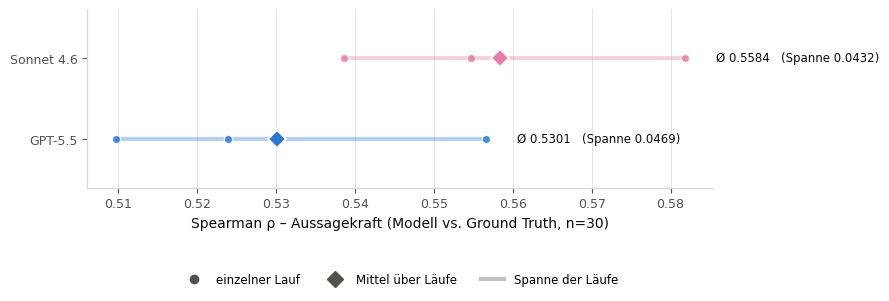

In [7]:
sortiert = sorted(rho30, key=lambda m: st.mean(rho30[m]))
fig, ax = plt.subplots(figsize=(9.0, 1.05 * len(sortiert) + 1.4))

for i, m in enumerate(sortiert):
    v = rho30[m]
    mittel = st.mean(v)
    ax.hlines(i, min(v), max(v), color=FARBEN_MODELL[m], linewidth=3, alpha=0.35, zorder=2)
    ax.plot(v, [i] * len(v), "o", markersize=6, color=FARBEN_MODELL[m], alpha=0.85,
            markeredgecolor="white", markeredgewidth=1.0, zorder=3)
    ax.plot(mittel, i, "D", markersize=9, color=FARBEN_MODELL[m], zorder=4,
            markeredgecolor="white", markeredgewidth=1.4)
    ax.text(max(v) + 0.004, i, f"Ø {mittel:.4f}   (Spanne {max(v) - min(v):.4f})",
            va="center", ha="left", fontsize=8.5, color=TEXT, zorder=5)

ax.set_yticks(range(len(sortiert)))
ax.set_yticklabels(sortiert, fontsize=10, color=TEXT)
ax.set_xlabel(f"Spearman ρ – {DIM_DE[LLM_DIM]} (Modell vs. Ground Truth, n=30)", fontsize=10, color=TEXT)
ax.set_ylim(-0.6, len(sortiert) - 0.4)
ax.set_axisbelow(True)
ax.grid(axis="x", linestyle="-", linewidth=0.6, color=GRID, alpha=0.8)
stil(ax)

handles = [
    Line2D([], [], marker="o", linestyle="none", color=TEXT_SEK, markersize=6, label="einzelner Lauf"),
    Line2D([], [], marker="D", linestyle="none", color=TEXT_SEK, markersize=8, label="Mittel über Läufe"),
    Line2D([], [], color=TEXT_SEK, linewidth=3, alpha=0.35, label="Spanne der Läufe"),
]
ax.legend(handles=handles, frameon=False, fontsize=8.5, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.42))
fig.tight_layout()
speichern(fig, "modellauswahl_wiederholungen")
plt.show()

## 5.7.1 Ground Truth — Kernstichprobe (n=50)

Primärmetrik (ρ je Dimension + Ceiling-Analyse), Kalibrierung (MAE/Bias) und Urteilsebene (Konfusionsmatrix), berechnet direkt aus `KERN_RUN` + `KERN_GT` — identisch zum GPT-5.5-Datenpunkt aus 5.6.1, hier nur um Ceiling und Disattenuation ergänzt.

In [8]:
def gt_auswertung(run, gt_csv):
    merged = gt.merge_scores(gt.load_ground_truth(REPO_ROOT / gt_csv), gt.load_model_scores(run_pfad(run)))
    result = gt.compare(merged)
    rows = {}
    for gt_col, dim in gt.DIM_MAP.items():
        x, y = merged[f"model_{dim}"], merged[gt_col]
        obs = result["per_dimension"].loc[dim, "spearman"]
        ceil = gt.ceiling_spearman(x, y)
        rows[dim] = {
            "spearman_beobachtet": float(obs),
            "spearman_ceiling": float(ceil) if ceil and not np.isnan(ceil) else None,
            "anteil_vom_ceiling": float(obs / ceil) if ceil and not np.isnan(ceil) else None,
            "kendall_tau_b": float(result["per_dimension"].loc[dim, "kendall_tau"]),
            "gt_stufen_genutzt": int(merged[gt_col].nunique()),
        }
    alpha_gt = gt.cronbach_alpha(merged[gt.GT_COLS])
    alpha_model = gt.cronbach_alpha(merged[[f"model_{d}" for d in gt.MODEL_DIMS]])
    r_obs = result["overall"]["spearman_overall"]
    r_true = gt.disattenuated_correlation(r_obs, alpha_gt, alpha_model)
    return {
        "merged": merged, "result": result, "ceiling_je_dimension": rows,
        "disattenuation": {
            "cronbach_alpha_gt": float(alpha_gt), "cronbach_alpha_modell": float(alpha_model),
            "spearman_beobachtet": float(r_obs),
            "spearman_disattenuiert": float(r_true) if not np.isnan(r_true) else None,
        },
    }


kern_gt_eval = gt_auswertung(KERN_RUN, KERN_GT)
kern_merged, kern_result = kern_gt_eval["merged"], kern_gt_eval["result"]

print("=== Kernstichprobe: Primärmetrik + Ceiling ===")
for d in DIMS:
    c = kern_gt_eval["ceiling_je_dimension"][d]
    print(f"  {DIM_DE[d]:<20} rho={c['spearman_beobachtet']:.3f}  "
          f"Ceiling={c['spearman_ceiling']:.3f}  Anteil={c['anteil_vom_ceiling']:.1%}")
print(f"  Gesamt               rho={kern_result['overall']['spearman_overall']:.3f}")
print()
print("Disattenuation:", kern_gt_eval["disattenuation"])
print()
print("Konfusionsmatrix:")
print(kern_result["confusion"])

loaded 50 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-16_11-10-53_state-evaluation-final_EVAL_gpt5-5


=== Kernstichprobe: Primärmetrik + Ceiling ===
  Auffindbarkeit       rho=0.524  Ceiling=0.768  Anteil=68.3%
  Zugänglichkeit       rho=0.712  Ceiling=0.952  Anteil=74.8%
  Wiederverwendbarkeit rho=0.739  Ceiling=0.928  Anteil=79.6%
  Aussagekraft         rho=0.569  Ceiling=0.851  Anteil=66.8%
  Gesamt               rho=0.765

Disattenuation: {'cronbach_alpha_gt': 0.5628074158153613, 'cronbach_alpha_modell': 0.2944845888703565, 'spearman_beobachtet': 0.7654631094008633, 'spearman_disattenuiert': 1.0}

Konfusionsmatrix:
             M:schlecht  M:mittel  M:gut
GT:schlecht           1         0      0
GT:mittel             0        42      2
GT:gut                0         2      3


geschrieben: thesis/images/gt_kernstichprobe_rho_dimension.png
geschrieben: thesis/images/gt_kernstichprobe_rho_dimension.pdf


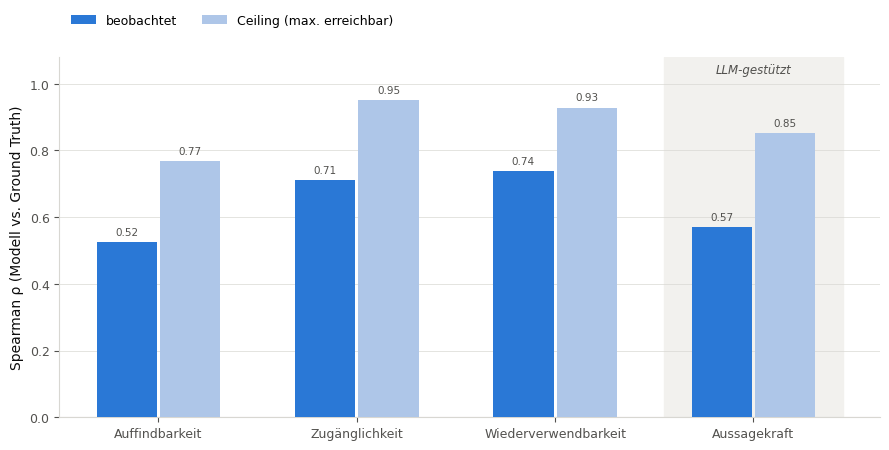

In [9]:
def fig_rho_ceiling(ceiling_je_dim, name):
    beob = [ceiling_je_dim[d]["spearman_beobachtet"] for d in DIMS]
    ceiling = [ceiling_je_dim[d]["spearman_ceiling"] for d in DIMS]

    fig, ax = plt.subplots(figsize=(9.0, 4.6))
    x, breite = np.arange(len(DIMS)), 0.32
    i_llm = DIMS.index(LLM_DIM)
    ax.axvspan(i_llm - 0.45, i_llm + 0.45, color="#f2f1ee", zorder=0)

    b1 = ax.bar(x - breite / 2, beob, breite * 0.95, label="beobachtet", color=HAUPT, zorder=3)
    b2 = ax.bar(x + breite / 2, ceiling, breite * 0.95, label="Ceiling (max. erreichbar)",
                color=CEILING, zorder=3)
    for bars in (b1, b2):
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width() / 2, h + 0.015, f"{h:.2f}", ha="center",
                    va="bottom", fontsize=7.5, color=TEXT_SEK, zorder=4)

    ax.set_ylabel("Spearman ρ (Modell vs. Ground Truth)", fontsize=10, color=TEXT)
    ax.set_ylim(0, 1.08)
    ax.set_xticks(x)
    ax.set_xticklabels([DIM_DE[d] for d in DIMS], fontsize=10, color=TEXT)
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="-", linewidth=0.6, color=GRID, alpha=0.8)
    ax.axhline(0, color=GRID, lw=0.8, zorder=2)
    stil(ax)
    ax.annotate("LLM-gestützt", xy=(i_llm, 1.03), ha="center", fontsize=8.5, color=TEXT_SEK, style="italic")
    ax.legend(frameon=False, fontsize=9, ncol=2, loc="upper left", bbox_to_anchor=(0.0, 1.15))
    fig.tight_layout()
    speichern(fig, name)
    plt.show()


fig_rho_ceiling(kern_gt_eval["ceiling_je_dimension"], "gt_kernstichprobe_rho_dimension")

geschrieben: thesis/images/gt_kernstichprobe_scatter.png
geschrieben: thesis/images/gt_kernstichprobe_scatter.pdf


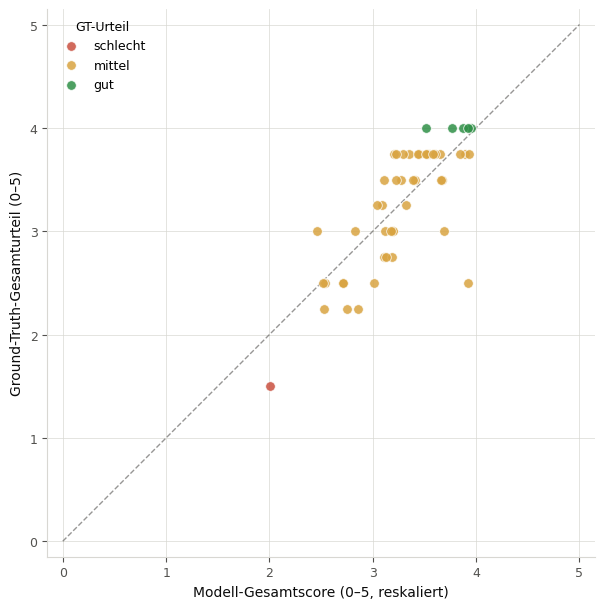

In [10]:
fig, ax = plt.subplots(figsize=(6.2, 6.2))
for v in gt.VERDICTS:
    sub = kern_merged[kern_merged["gt_verdict"] == v]
    ax.scatter(sub["model_overall_0_5"], sub["gt_overall"], label=v, s=48,
               color=VERDICT[v], alpha=0.85, edgecolor="white", linewidth=0.6, zorder=3)
ax.plot([0, 5], [0, 5], linestyle="--", color=TEXT_SEK, lw=1, alpha=0.6, zorder=2)
ax.set_xlabel("Modell-Gesamtscore (0–5, reskaliert)", fontsize=10, color=TEXT)
ax.set_ylabel("Ground-Truth-Gesamturteil (0–5)", fontsize=10, color=TEXT)
ax.set_xlim(-0.15, 5.15)
ax.set_ylim(-0.15, 5.15)
ax.set_aspect("equal")
ax.set_axisbelow(True)
ax.grid(linestyle="-", linewidth=0.6, color=GRID, alpha=0.8)
stil(ax)
ax.legend(title="GT-Urteil", frameon=False, fontsize=9, title_fontsize=9, loc="upper left")
fig.tight_layout()
speichern(fig, "gt_kernstichprobe_scatter")
plt.show()

geschrieben: thesis/images/gt_kernstichprobe_konfusionsmatrix.png
geschrieben: thesis/images/gt_kernstichprobe_konfusionsmatrix.pdf


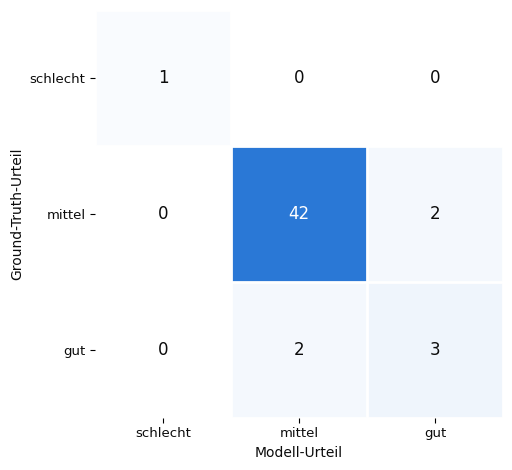

In [11]:
cmap_haupt = LinearSegmentedColormap.from_list("haupt", ["#ffffff", HAUPT])


def fig_konfusion(confusion_df, name):
    data = confusion_df.to_numpy()
    fig, ax = plt.subplots(figsize=(5.2, 4.8))
    ax.imshow(data, cmap=cmap_haupt, vmin=0, vmax=data.max())
    ax.set_xticks(range(len(confusion_df.columns)))
    ax.set_xticklabels([c.replace("M:", "") for c in confusion_df.columns], fontsize=9.5, color=TEXT)
    ax.set_yticks(range(len(confusion_df.index)))
    ax.set_yticklabels([i.replace("GT:", "") for i in confusion_df.index], fontsize=9.5, color=TEXT)
    ax.set_xlabel("Modell-Urteil", fontsize=10, color=TEXT)
    ax.set_ylabel("Ground-Truth-Urteil", fontsize=10, color=TEXT)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = int(data[i, j])
            farbe = "white" if val > data.max() * 0.55 else TEXT
            ax.text(j, i, val, ha="center", va="center", color=farbe, fontsize=12, zorder=3)
    for r in ax.spines.values():
        r.set_visible(False)
    ax.set_xticks(np.arange(-0.5, len(confusion_df.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(confusion_df.index), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="minor", length=0)
    fig.tight_layout()
    speichern(fig, name)
    plt.show()


fig_konfusion(kern_result["confusion"], "gt_kernstichprobe_konfusionsmatrix")

## 5.7.2 Ground Truth — Extremfälle (n=20)

Dieselbe Auswertung, jetzt auf `EXTREM_RUN` + `EXTREM_GT`, ergänzt um die Trennschärfe zwischen den konstruierten Gruppen (`good_*`/`bad_*`).

loaded 20 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-22_09-23-07_state-evaluation-final_EVAL


=== Extremfälle: Primärmetrik + Ceiling ===
  Auffindbarkeit       rho=0.874  Ceiling=0.967  Anteil=90.3%
  Zugänglichkeit       rho=0.713  Ceiling=0.978  Anteil=72.9%
  Wiederverwendbarkeit rho=0.872  Ceiling=0.957  Anteil=91.0%
  Aussagekraft         rho=0.321  Ceiling=0.942  Anteil=34.1%
  Gesamt               rho=0.827

Disattenuation: {'cronbach_alpha_gt': 0.8900935086055021, 'cronbach_alpha_modell': 0.8366047330485437, 'spearman_beobachtet': 0.8271705393371815, 'spearman_disattenuiert': 0.9585551008897443}

Konfusionsmatrix:
             M:schlecht  M:mittel  M:gut
GT:schlecht           3         2      0
GT:mittel             3         4      4
GT:gut                0         1      3
geschrieben: thesis/images/gt_extremfaelle_rho_dimension.png
geschrieben: thesis/images/gt_extremfaelle_rho_dimension.pdf


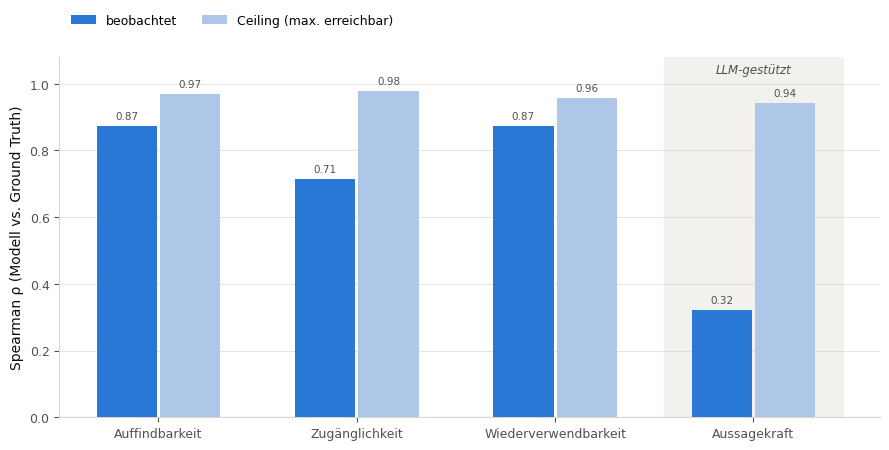

In [12]:
extrem_gt_eval = gt_auswertung(EXTREM_RUN, EXTREM_GT)
extrem_merged, extrem_result = extrem_gt_eval["merged"], extrem_gt_eval["result"]

print("=== Extremfälle: Primärmetrik + Ceiling ===")
for d in DIMS:
    c = extrem_gt_eval["ceiling_je_dimension"][d]
    print(f"  {DIM_DE[d]:<20} rho={c['spearman_beobachtet']:.3f}  "
          f"Ceiling={c['spearman_ceiling']:.3f}  Anteil={c['anteil_vom_ceiling']:.1%}")
print(f"  Gesamt               rho={extrem_result['overall']['spearman_overall']:.3f}")
print()
print("Disattenuation:", extrem_gt_eval["disattenuation"])
print()
print("Konfusionsmatrix:")
print(extrem_result["confusion"])

fig_rho_ceiling(extrem_gt_eval["ceiling_je_dimension"], "gt_extremfaelle_rho_dimension")

In [13]:
# Verifikation der im Fliesstext zitierten Einzelbeispiele (bad_09.rdf,
# good_02.rdf) und des "schmales Band"-Befunds -- direkt aus extrem_merged
# nachvollziehbar, keine Zahl ausserhalb dieses Notebooks.
mismatch = extrem_merged[extrem_merged["gt_verdict"] != extrem_merged["model_verdict"]]
mismatch_cols = ["file", "gt_verdict", "model_verdict", "gt_expressiveness", "model_expressiveness_0_5"]
print(f"Fehlklassifikationen: {len(mismatch)}/{len(extrem_merged)} "
      f"(Accuracy = {1 - len(mismatch) / len(extrem_merged):.2f})")
print(mismatch[mismatch_cols].round(2).to_string(index=False))
print()
band = mismatch["model_expressiveness_0_5"]
print(f"Modell-Aussagekraftswert unter den Fehlklassifikationen: "
      f"min={band.min():.2f}  max={band.max():.2f}  (Skala 0-5)")

for f in ["bad_09.rdf", "good_02.rdf"]:
    row = extrem_merged.loc[extrem_merged["file"] == f].iloc[0]
    print(f"  {f}: GT={row['gt_expressiveness']:.0f}  Modell={row['model_expressiveness_0_5']:.1f}")

# Indikator-Ebene fuer bad_09.rdf direkt aus dem Lauf -- Beleg fuer den
# Aggregations-Mechanismus (ein hartes Einzeldefizit wird durch fuenf
# unauffaellige Werte neutralisiert).
bad09_result = json.loads((run_pfad(EXTREM_RUN) / "bad_09" / "result.json").read_text(encoding="utf-8"))
expr_indicators = bad09_result["by_dimension"]["expressiveness"]["indicators"]
print("\nbad_09.rdf -- Aussagekraft-Teilkriterien:")
for ind in expr_indicators:
    print(f"  {ind['indicator_id']:<38} {ind['status']:<10} score={ind['score']:.2f}")
scores = [ind["score"] for ind in expr_indicators]
print(f"  Mittelwert (= Dimensionswert)      : {sum(scores) / len(scores):.3f}")

extrem_beispiele = {
    "n_fehlklassifikationen": int(len(mismatch)),
    "n_gesamt": int(len(extrem_merged)),
    "modell_aussagekraft_band_bei_fehlklassifikation": {"min": float(band.min()), "max": float(band.max())},
    "bad_09": {"gt_expressiveness": 1, "model_expressiveness_0_5": float(
        extrem_merged.loc[extrem_merged["file"] == "bad_09.rdf", "model_expressiveness_0_5"].iloc[0]),
        "teilkriterien": {ind["indicator_id"]: ind["score"] for ind in expr_indicators}},
    "good_02": {"gt_expressiveness": 2, "model_expressiveness_0_5": float(
        extrem_merged.loc[extrem_merged["file"] == "good_02.rdf", "model_expressiveness_0_5"].iloc[0])},
}

Fehlklassifikationen: 10/20 (Accuracy = 0.50)
       file gt_verdict model_verdict  gt_expressiveness  model_expressiveness_0_5
 bad_03.rdf     mittel      schlecht                  3                      3.61
 bad_04.rdf   schlecht        mittel                  2                      3.96
 bad_05.rdf     mittel      schlecht                  3                      3.82
 bad_08.rdf     mittel      schlecht                  3                      3.63
 bad_09.rdf   schlecht        mittel                  1                      3.58
good_02.rdf     mittel           gut                  2                      3.83
good_04.rdf     mittel           gut                  3                      4.00
good_06.rdf        gut        mittel                  4                      3.34
good_08.rdf     mittel           gut                  4                      4.27
good_09.rdf     mittel           gut                  4                      4.33

Modell-Aussagekraftswert unter den Fehlklassifikati

geschrieben: thesis/images/gt_extremfaelle_trennschaerfe.png


geschrieben: thesis/images/gt_extremfaelle_trennschaerfe.pdf


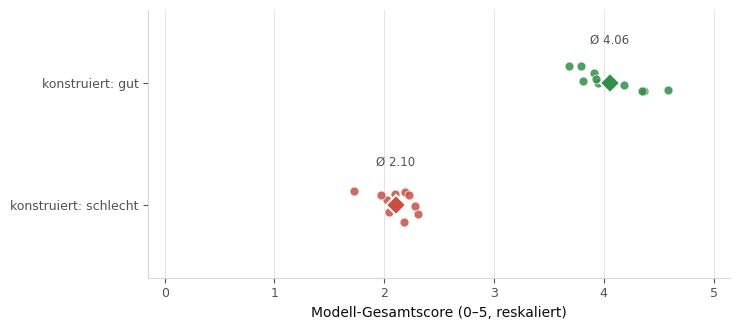

In [14]:
extrem_merged["gruppe"] = np.where(
    extrem_merged["file"].str.startswith("good_"), "konstruiert: gut", "konstruiert: schlecht"
)
gruppen_gt = ["konstruiert: schlecht", "konstruiert: gut"]

fig, ax = plt.subplots(figsize=(7.5, 3.4))
rng = np.random.default_rng(7)
for i, gname in enumerate(gruppen_gt):
    sub = extrem_merged[extrem_merged["gruppe"] == gname]
    jitter = rng.uniform(-0.14, 0.14, size=len(sub))
    ax.scatter(sub["model_overall_0_5"], np.full(len(sub), i) + jitter, s=42,
               color=(VERDICT["schlecht"] if "schlecht" in gname else VERDICT["gut"]),
               alpha=0.85, edgecolor="white", linewidth=0.6, zorder=3)
    mittel = sub["model_overall_0_5"].mean()
    ax.plot(mittel, i, "D", markersize=10,
            color=(VERDICT["schlecht"] if "schlecht" in gname else VERDICT["gut"]),
            markeredgecolor="white", markeredgewidth=1.4, zorder=4)
    ax.text(mittel, i + 0.32, f"Ø {mittel:.2f}", ha="center", fontsize=8.5, color=TEXT_SEK)

ax.set_yticks(range(len(gruppen_gt)))
ax.set_yticklabels(gruppen_gt, fontsize=10, color=TEXT)
ax.set_xlabel("Modell-Gesamtscore (0–5, reskaliert)", fontsize=10, color=TEXT)
ax.set_xlim(-0.15, 5.15)
ax.set_ylim(-0.6, len(gruppen_gt) - 0.4)
ax.set_axisbelow(True)
ax.grid(axis="x", linestyle="-", linewidth=0.6, color=GRID, alpha=0.8)
stil(ax)
fig.tight_layout()
speichern(fig, "gt_extremfaelle_trennschaerfe")
plt.show()

## 5.8.1 MQA — Kernstichprobe (n=50)

Prototyp-Seite aus `KERN_RUN` geladen (kein Rescoring), MQA-Seite aus dem gecachten `KERN_MQA_CACHE` (deterministisch, unabhängig vom Prototyp-Modell — nur die HTTP-Probe-Ergebnisse zählen, RDF-Dateien sind identisch zu 5.7.1).

In [15]:
def mqa_join(model_run, mqa_cache_csv):
    model_long = ij.load_model_indicators_from_run(run_pfad(model_run))
    mqa_long = pd.read_csv(run_pfad(mqa_cache_csv))
    join = ij.build_join(model_long, mqa_long)
    summ = ij.summarise(join)
    return join, summ, model_long, mqa_long


def scatter_and_triangulate(model_long, mqa_long, gt_csv):
    mqa_per_file = (
        mqa_long.groupby("file")
        .apply(lambda g: pd.Series({"mqa_score_norm": g["mqa_points"].sum() / g["mqa_max"].sum()
                                     if g["mqa_max"].sum() > 0 else float("nan")}))
        .reset_index()
    )
    model_per_file = (model_long.groupby("file")["model_overall"].first()
                       .reset_index().rename(columns={"model_overall": "model_score_norm"}))
    scatter_df = mqa_per_file.merge(model_per_file, on="file")

    gt_df = pd.read_csv(REPO_ROOT / gt_csv)
    gt_df["gt_overall"] = gt_df[[f"gt_{d}" for d in DIMS]].mean(axis=1)
    gt_df["gt_overall_ohne_expr"] = gt_df[[f"gt_{d}" for d in DIMS[:3]]].mean(axis=1)
    tri = gt_df.merge(scatter_df[["file", "model_score_norm", "mqa_score_norm"]], on="file")

    targets = ([("gesamt (4 Dim.)", "gt_overall"), ("ohne Expressiveness (3 Dim.)", "gt_overall_ohne_expr")]
               + [(d, f"gt_{d}") for d in DIMS])
    rows = [{"ziel": lbl,
             "prot_rho": spearman_np(tri["model_score_norm"].to_numpy(), tri[col].to_numpy(dtype=float)),
             "mqa_rho": spearman_np(tri["mqa_score_norm"].to_numpy(), tri[col].to_numpy(dtype=float))}
            for lbl, col in targets]
    tri_df = pd.DataFrame(rows)
    tri_df["delta"] = tri_df["prot_rho"] - tri_df["mqa_rho"]
    return scatter_df, tri_df


kern_join, kern_mqa_summ, kern_model_long, kern_mqa_long = mqa_join(KERN_RUN, KERN_MQA_CACHE)
kern_scatter, kern_tri = scatter_and_triangulate(kern_model_long, kern_mqa_long, KERN_GT)

print("Klassenzählung A/B/C:", kern_mqa_summ["class_counts"])
print("[A] Konvergenz:", kern_mqa_summ["class_a"])
print()
print("Triangulation (H3):")
print(kern_tri.round(3).to_string(index=False))

loaded model indicators from existing run: /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-16_11-10-53_state-evaluation-final_EVAL_gpt5-5 (50 files)


Klassenzählung A/B/C: {'B': 9, 'C': 9, 'A': 9}
[A] Konvergenz: {'n': 450, 'agreement': 0.96, 'both_pass': 298, 'both_fail': 134, 'mqa_pass_model_fail': 17, 'model_pass_mqa_fail': 1}

Triangulation (H3):
                        ziel  prot_rho  mqa_rho  delta
             gesamt (4 Dim.)     0.750    0.704  0.046
ohne Expressiveness (3 Dim.)     0.688    0.655  0.033
                 findability     0.225    0.288 -0.064
               accessibility     0.588    0.569  0.019
                 reusability     0.441    0.377  0.064
              expressiveness     0.651    0.571  0.080


geschrieben: thesis/images/mqa_konvergenz_matrix.png
geschrieben: thesis/images/mqa_konvergenz_matrix.pdf


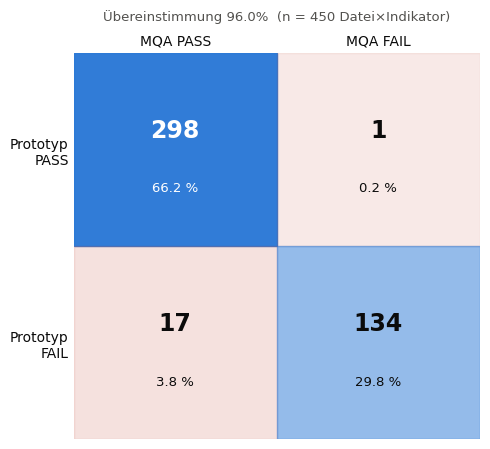

In [16]:
def fig_konvergenz(summ, name):
    a = summ["class_a"]
    mat = np.array([[a["both_pass"], a["model_pass_mqa_fail"]],
                     [a["mqa_pass_model_fail"], a["both_fail"]]], dtype=float)
    total = mat.sum()
    agree_mask = np.array([[True, False], [False, True]])

    fig, ax = plt.subplots(figsize=(5.0, 4.6))
    for i in range(2):
        for j in range(2):
            base = HAUPT if agree_mask[i, j] else DISAGREE
            alpha = 0.12 + 0.85 * (mat[i, j] / mat.max())
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, color=(*mcolors.to_rgb(base), alpha), zorder=1))
            val = int(mat[i, j])
            farbe = "white" if alpha > 0.55 else TEXT
            ax.text(j, i - 0.10, str(val), ha="center", va="center", fontsize=17, fontweight="bold",
                    color=farbe, zorder=3)
            ax.text(j, i + 0.20, f"{100 * val / total:.1f} %", ha="center", va="center", fontsize=9.5,
                    color=farbe, zorder=3)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["MQA PASS", "MQA FAIL"], fontsize=10, color=TEXT)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Prototyp\nPASS", "Prototyp\nFAIL"], fontsize=10, color=TEXT)
    ax.xaxis.set_label_position("top"); ax.xaxis.tick_top()
    for r in ax.spines.values():
        r.set_visible(False)
    ax.tick_params(length=0)
    ax.set_title(f"Übereinstimmung {a['agreement']:.1%}  (n = {a['n']} Datei×Indikator)",
                 fontsize=9.5, color=TEXT_SEK, pad=10)
    fig.tight_layout()
    speichern(fig, name)
    plt.show()


fig_konvergenz(kern_mqa_summ, "mqa_konvergenz_matrix")

geschrieben: thesis/images/mqa_ueberschaetzung.png


geschrieben: thesis/images/mqa_ueberschaetzung.pdf


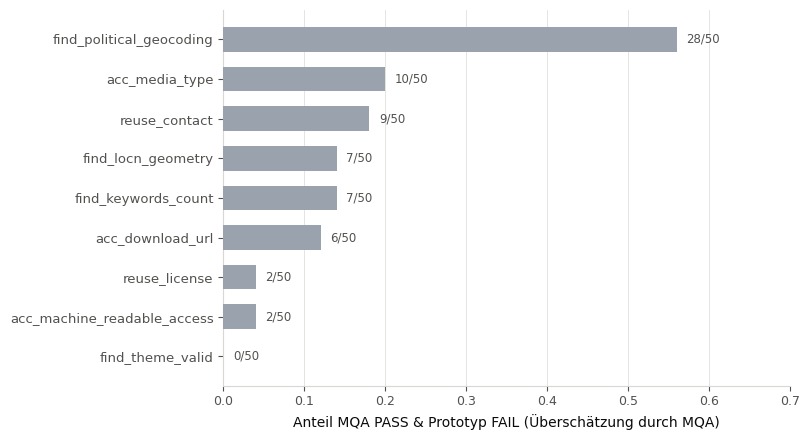

In [17]:
def fig_ueberschaetzung(summ, name):
    b = summ["class_b"].sort_values("overestimation_rate", ascending=True)
    fig, ax = plt.subplots(figsize=(8.2, max(2.6, len(b) * 0.5)))
    farben = [MQA if r > 0 else CEILING for r in b["overestimation_rate"]]
    bars = ax.barh(b["indicator"], b["overestimation_rate"], color=farben, zorder=3, height=0.62)
    for bar, (_, row) in zip(bars, b.iterrows()):
        ax.text(bar.get_width() + 0.012, bar.get_y() + bar.get_height() / 2,
                f"{int(row['mqa_pass_model_fail'])}/{int(row['n'])}", va="center", fontsize=8.5, color=TEXT_SEK)
    ax.set_xlabel("Anteil MQA PASS & Prototyp FAIL (Überschätzung durch MQA)", fontsize=10, color=TEXT)
    ax.set_xlim(0, max(0.65, b["overestimation_rate"].max() * 1.25))
    ax.set_axisbelow(True)
    ax.grid(axis="x", linestyle="-", linewidth=0.6, color=GRID, alpha=0.8)
    stil(ax)
    ax.tick_params(axis="y", labelsize=9.5)
    fig.tight_layout()
    speichern(fig, name)
    plt.show()


fig_ueberschaetzung(kern_mqa_summ, "mqa_ueberschaetzung")

geschrieben: thesis/images/mqa_blindheit_boxplot.png
geschrieben: thesis/images/mqa_blindheit_boxplot.pdf


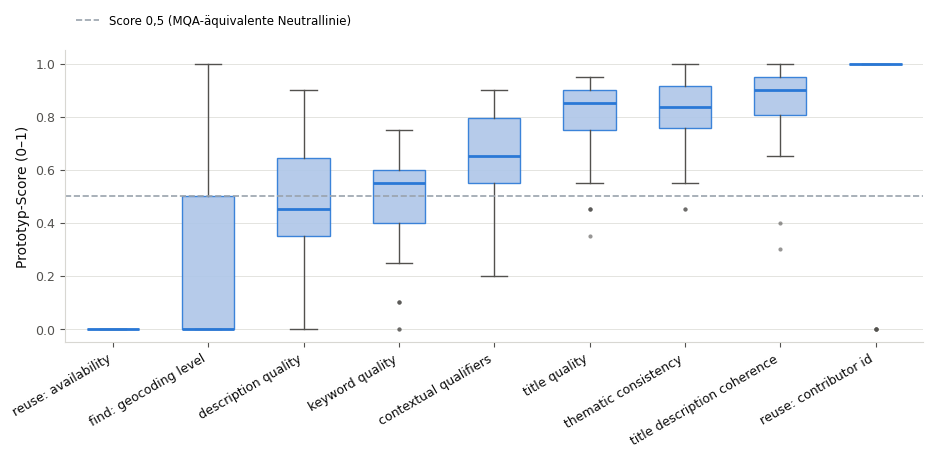

In [18]:
c_inds = kern_mqa_summ["class_c"]["indicator"].tolist()
c_data = [kern_join.loc[(kern_join["indicator"] == ind) & kern_join["model_score"].notna(), "model_score"]
          .astype(float).tolist() for ind in c_inds]
c_labels = [i.replace("expr_", "").replace("reuse_", "reuse: ").replace("find_", "find: ").replace("_", " ")
            for i in c_inds]

fig, ax = plt.subplots(figsize=(9.5, 4.8))
bp = ax.boxplot(c_data, tick_labels=c_labels, patch_artist=True, widths=0.55,
                medianprops=dict(color=HAUPT, lw=2),
                whiskerprops=dict(color=TEXT_SEK), capprops=dict(color=TEXT_SEK),
                flierprops=dict(marker="o", markersize=3, markerfacecolor=TEXT_SEK,
                                markeredgecolor="none", alpha=0.6))
for box in bp["boxes"]:
    box.set_facecolor(CEILING)
    box.set_edgecolor(HAUPT)
    box.set_alpha(0.9)
ax.axhline(0.5, color=MQA, lw=1.2, ls="--", zorder=2, label="Score 0,5 (MQA-äquivalente Neutrallinie)")
ax.set_ylabel("Prototyp-Score (0–1)", fontsize=10, color=TEXT)
ax.set_ylim(-0.05, 1.05)
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="-", linewidth=0.6, color=GRID, alpha=0.8)
stil(ax)
plt.setp(ax.get_xticklabels(), fontsize=9, color=TEXT, rotation=30, ha="right")
ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(0.0, 1.16))
fig.tight_layout()
speichern(fig, "mqa_blindheit_boxplot")
plt.show()

geschrieben: thesis/images/mqa_scatter_gesamt.png


geschrieben: thesis/images/mqa_scatter_gesamt.pdf


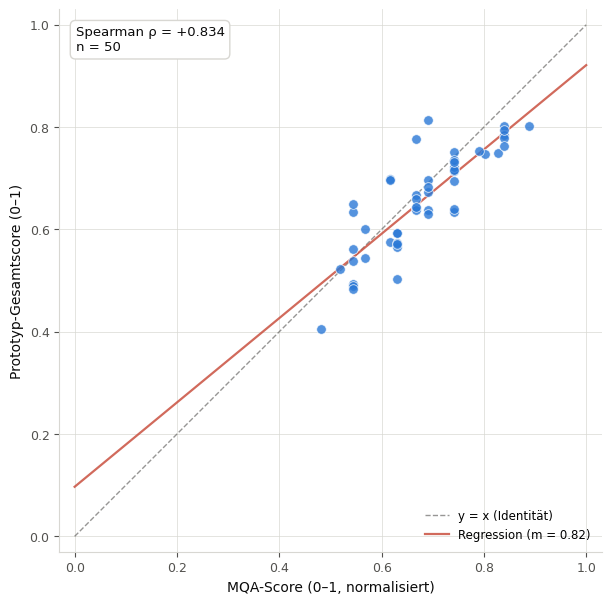

{'rho': 0.8338760650198049, 'n': 50, 'mean_diff_prot_minus_mqa': -0.022227586144849276, 'median_diff_prot_minus_mqa': -0.03214705210319235, 'regression_slope': 0.8241993764093967, 'regression_intercept': 0.09692616984433752}


In [19]:
def fig_scatter_mqa(scatter_df, name):
    x = scatter_df["mqa_score_norm"].to_numpy(float)
    y = scatter_df["model_score_norm"].to_numpy(float)
    valid = ~(np.isnan(x) | np.isnan(y))
    xv, yv = x[valid], y[valid]
    sp = spearman_np(xv, yv)
    m, b_coef = np.polyfit(xv, yv, 1)
    x_line = np.linspace(0, 1, 100)

    fig, ax = plt.subplots(figsize=(6.2, 6.2))
    ax.plot([0, 1], [0, 1], linestyle="--", color=TEXT_SEK, lw=1, alpha=0.6, zorder=2, label="y = x (Identität)")
    ax.plot(x_line, m * x_line + b_coef, color=VERDICT["schlecht"], lw=1.6, alpha=0.85, zorder=2,
            label=f"Regression (m = {m:.2f})")
    ax.scatter(xv, yv, s=48, color=HAUPT, alpha=0.8, edgecolor="white", linewidth=0.6, zorder=3)
    ax.text(0.03, 0.97, f"Spearman ρ = {sp:+.3f}\nn = {len(xv)}", transform=ax.transAxes,
            va="top", ha="left", fontsize=9.5, color=TEXT,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor=GRID))
    ax.set_xlabel("MQA-Score (0–1, normalisiert)", fontsize=10, color=TEXT)
    ax.set_ylabel("Prototyp-Gesamtscore (0–1)", fontsize=10, color=TEXT)
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-0.03, 1.03)
    ax.set_aspect("equal")
    ax.set_axisbelow(True)
    ax.grid(linestyle="-", linewidth=0.6, color=GRID, alpha=0.8)
    stil(ax)
    ax.legend(frameon=False, fontsize=8.5, loc="lower right")
    fig.tight_layout()
    speichern(fig, name)
    plt.show()
    return {"rho": sp, "n": int(len(xv)), "mean_diff_prot_minus_mqa": float(np.mean(yv - xv)),
            "median_diff_prot_minus_mqa": float(np.median(yv - xv)),
            "regression_slope": float(m), "regression_intercept": float(b_coef)}


kern_scatter_stats = fig_scatter_mqa(kern_scatter, "mqa_scatter_gesamt")
print(kern_scatter_stats)

geschrieben: thesis/images/mqa_triangulation_kernstichprobe.png
geschrieben: thesis/images/mqa_triangulation_kernstichprobe.pdf


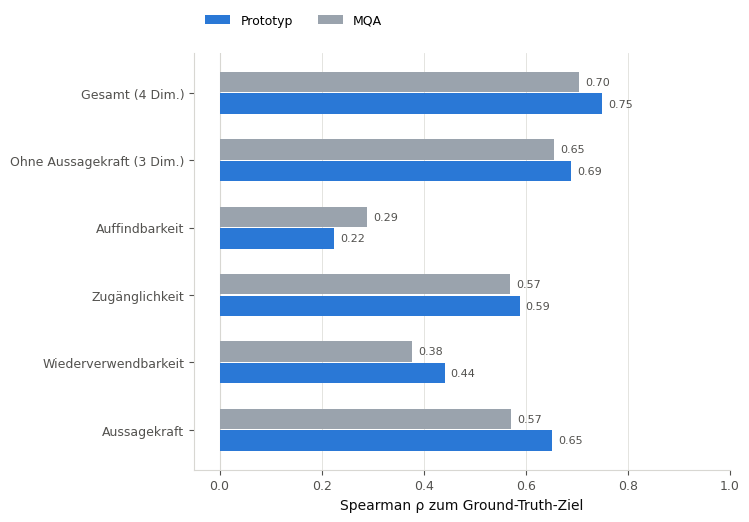

In [20]:
def fig_triangulation(tri, name):
    labels = [TRI_DIM_DE[z] for z in tri["ziel"]]
    y = np.arange(len(tri))
    hoehe = 0.32

    fig, ax = plt.subplots(figsize=(7.6, 0.72 * len(tri) + 1.0))
    b1 = ax.barh(y + hoehe / 2, tri["prot_rho"], hoehe * 0.95, color=HAUPT, label="Prototyp", zorder=3)
    b2 = ax.barh(y - hoehe / 2, tri["mqa_rho"], hoehe * 0.95, color=MQA, label="MQA", zorder=3)
    for bars in (b1, b2):
        for bar in bars:
            w = bar.get_width()
            ax.text(w + (0.012 if w >= 0 else -0.012), bar.get_y() + bar.get_height() / 2,
                    f"{w:.2f}", va="center", ha="left" if w >= 0 else "right", fontsize=8, color=TEXT_SEK)
    ax.axvline(0, color=GRID, lw=0.8, zorder=2)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9.5, color=TEXT)
    ax.invert_yaxis()
    ax.set_xlabel("Spearman ρ zum Ground-Truth-Ziel", fontsize=10, color=TEXT)
    ax.set_xlim(min(-0.05, tri[["prot_rho", "mqa_rho"]].min().min() - 0.08), 1.0)
    ax.set_axisbelow(True)
    ax.grid(axis="x", linestyle="-", linewidth=0.6, color=GRID, alpha=0.8)
    stil(ax)
    ax.legend(frameon=False, fontsize=9, ncol=2, loc="upper left", bbox_to_anchor=(0.0, 1.12))
    fig.tight_layout()
    speichern(fig, name)
    plt.show()


fig_triangulation(kern_tri, "mqa_triangulation_kernstichprobe")

## 5.8.2 MQA — Extremfälle (n=20)

Prototyp-Seite aus `EXTREM_RUN`, MQA-Seite aus `EXTREM_MQA_CACHE` (bereits live geprobt, siehe Notebook 17 — hier nur gelesen, kein erneuter HTTP-Call).

loaded model indicators from existing run: /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-22_09-23-07_state-evaluation-final_EVAL (20 files)


Klassenzählung A/B/C: {'B': 9, 'C': 9, 'A': 9}
[A] Konvergenz: {'n': 180, 'agreement': 0.9555555555555556, 'both_pass': 116, 'both_fail': 56, 'mqa_pass_model_fail': 8, 'model_pass_mqa_fail': 0}

Triangulation (H3):
                        ziel  prot_rho  mqa_rho  delta
             gesamt (4 Dim.)     0.837    0.721  0.116
ohne Expressiveness (3 Dim.)     0.834    0.718  0.116
                 findability     0.783    0.706  0.077
               accessibility     0.862    0.766  0.096
                 reusability     0.815    0.751  0.064
              expressiveness     0.533    0.398  0.136
geschrieben: thesis/images/mqa_triangulation_extremfaelle.png


geschrieben: thesis/images/mqa_triangulation_extremfaelle.pdf


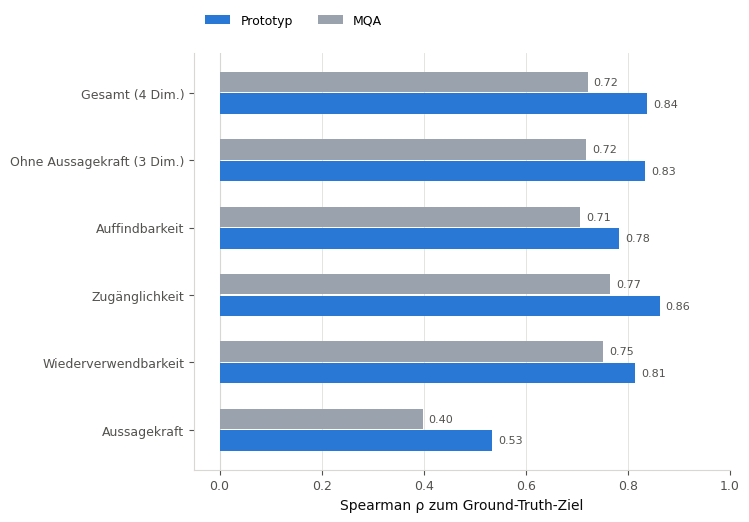

In [21]:
extrem_join, extrem_mqa_summ, extrem_model_long, extrem_mqa_long = mqa_join(EXTREM_RUN, EXTREM_MQA_CACHE)
extrem_scatter, extrem_tri = scatter_and_triangulate(extrem_model_long, extrem_mqa_long, EXTREM_GT)

print("Klassenzählung A/B/C:", extrem_mqa_summ["class_counts"])
print("[A] Konvergenz:", extrem_mqa_summ["class_a"])
print()
print("Triangulation (H3):")
print(extrem_tri.round(3).to_string(index=False))

fig_triangulation(extrem_tri, "mqa_triangulation_extremfaelle")

geschrieben: thesis/images/mqa_extremfaelle_trennschaerfe.png


geschrieben: thesis/images/mqa_extremfaelle_trennschaerfe.pdf


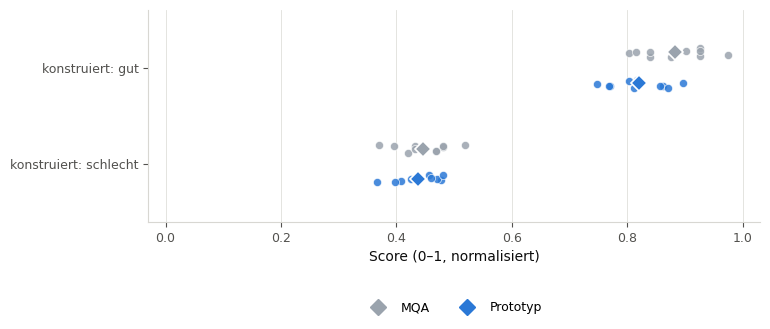

In [22]:
extrem_scatter["gruppe"] = np.where(
    extrem_scatter["file"].str.startswith("good_"), "konstruiert: gut", "konstruiert: schlecht"
)
gruppen_mqa = ["konstruiert: schlecht", "konstruiert: gut"]
systeme = [("mqa_score_norm", "MQA", MQA), ("model_score_norm", "Prototyp", HAUPT)]

fig, ax = plt.subplots(figsize=(7.8, 3.6))
rng = np.random.default_rng(7)
y_offsets = {"MQA": 0.16, "Prototyp": -0.16}
for i, gname in enumerate(gruppen_mqa):
    sub = extrem_scatter[extrem_scatter["gruppe"] == gname]
    for col, sys_label, farbe in systeme:
        y0 = i + y_offsets[sys_label]
        jitter = rng.uniform(-0.05, 0.05, size=len(sub))
        ax.scatter(sub[col], np.full(len(sub), y0) + jitter, s=34, color=farbe, alpha=0.85,
                   edgecolor="white", linewidth=0.5, zorder=3)
        mittel = sub[col].mean()
        ax.plot(mittel, y0, "D", markersize=8, color=farbe, markeredgecolor="white",
                markeredgewidth=1.2, zorder=4)

ax.set_yticks(range(len(gruppen_mqa)))
ax.set_yticklabels(gruppen_mqa, fontsize=10, color=TEXT)
ax.set_xlabel("Score (0–1, normalisiert)", fontsize=10, color=TEXT)
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.6, len(gruppen_mqa) - 0.4)
ax.set_axisbelow(True)
ax.grid(axis="x", linestyle="-", linewidth=0.6, color=GRID, alpha=0.8)
stil(ax)
handles = [Line2D([], [], marker="D", linestyle="none", color=farbe, markersize=8, label=lbl)
           for _, lbl, farbe in systeme]
ax.legend(handles=handles, frameon=False, fontsize=9, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.32))
fig.tight_layout()
speichern(fig, "mqa_extremfaelle_trennschaerfe")
plt.show()

### Abbildungen zur Extremfall-Analyse (Anhang der Thesis)

Dieselben vier Darstellungen wie in 5.8.1, hier auf den Extremfaellen. Sie stehen im
Anhang und nicht im Fliesstext, weil die Extremfaelle konstruiert sind und keine
verallgemeinerbare Aussage tragen -- im Text wird auf sie verwiesen.


geschrieben: thesis/images/mqa_extremfaelle_konvergenz_matrix.png


geschrieben: thesis/images/mqa_extremfaelle_konvergenz_matrix.pdf


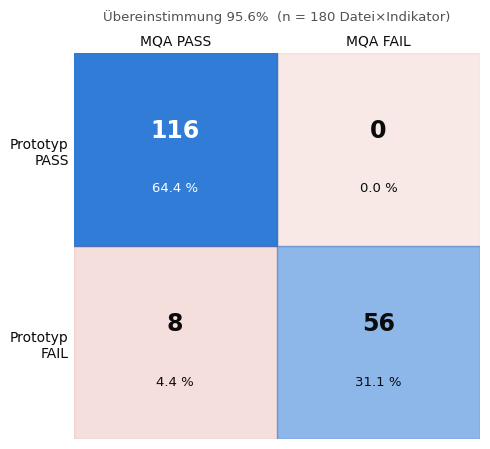

geschrieben: thesis/images/mqa_extremfaelle_ueberschaetzung.png


geschrieben: thesis/images/mqa_extremfaelle_ueberschaetzung.pdf


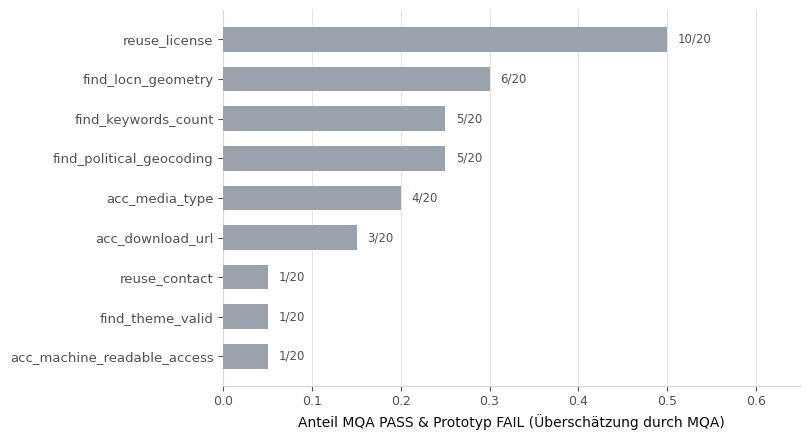

geschrieben: thesis/images/mqa_extremfaelle_blindheit_boxplot.png
geschrieben: thesis/images/mqa_extremfaelle_blindheit_boxplot.pdf


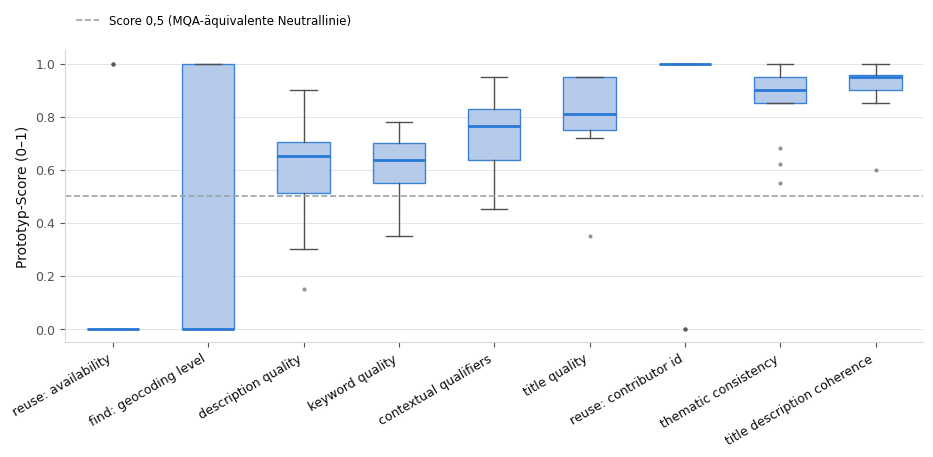

geschrieben: thesis/images/mqa_extremfaelle_scatter_gesamt.png
geschrieben: thesis/images/mqa_extremfaelle_scatter_gesamt.pdf


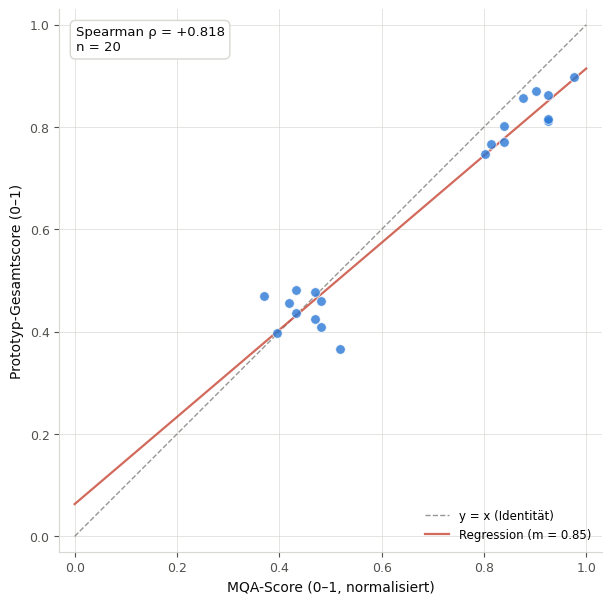

{'rho': 0.8182541000660263, 'n': 20, 'mean_diff_prot_minus_mqa': -0.03572180922391448, 'median_diff_prot_minus_mqa': -0.040445915358196055, 'regression_slope': 0.8513921372287956, 'regression_intercept': 0.06307489954434899}


In [23]:
# Die drei Funktionen aus 5.8.1 (fig_konvergenz, fig_ueberschaetzung,
# fig_scatter_mqa) werden unveraendert wiederverwendet. Nur der Klasse-C-Boxplot
# lag dort als Inline-Code vor und wird hier einmal als Funktion gefasst, damit
# Kern- und Extremfall-Abbildung garantiert identisch aufgebaut sind.
def fig_blindheit(summ, join, name):
    c_inds = summ["class_c"]["indicator"].tolist()
    c_data = [join.loc[(join["indicator"] == ind) & join["model_score"].notna(), "model_score"]
              .astype(float).tolist() for ind in c_inds]
    c_labels = [i.replace("expr_", "").replace("reuse_", "reuse: ").replace("find_", "find: ")
                 .replace("_", " ") for i in c_inds]

    fig, ax = plt.subplots(figsize=(9.5, 4.8))
    bp = ax.boxplot(c_data, tick_labels=c_labels, patch_artist=True, widths=0.55,
                    medianprops=dict(color=HAUPT, lw=2),
                    whiskerprops=dict(color=TEXT_SEK), capprops=dict(color=TEXT_SEK),
                    flierprops=dict(marker="o", markersize=3, markerfacecolor=TEXT_SEK,
                                    markeredgecolor="none", alpha=0.6))
    for box in bp["boxes"]:
        box.set_facecolor(CEILING)
        box.set_edgecolor(HAUPT)
        box.set_alpha(0.9)
    ax.axhline(0.5, color=MQA, lw=1.2, ls="--", zorder=2,
               label="Score 0,5 (MQA-äquivalente Neutrallinie)")
    ax.set_ylabel("Prototyp-Score (0–1)", fontsize=10, color=TEXT)
    ax.set_ylim(-0.05, 1.05)
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="-", linewidth=0.6, color=GRID, alpha=0.8)
    stil(ax)
    plt.setp(ax.get_xticklabels(), fontsize=9, color=TEXT, rotation=30, ha="right")
    ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(0.0, 1.16))
    fig.tight_layout()
    speichern(fig, name)
    plt.show()


fig_konvergenz(extrem_mqa_summ, "mqa_extremfaelle_konvergenz_matrix")
fig_ueberschaetzung(extrem_mqa_summ, "mqa_extremfaelle_ueberschaetzung")
fig_blindheit(extrem_mqa_summ, extrem_join, "mqa_extremfaelle_blindheit_boxplot")
extrem_scatter_stats = fig_scatter_mqa(extrem_scatter, "mqa_extremfaelle_scatter_gesamt")
print(extrem_scatter_stats)


## Kennzahlen-Export — eine Datei für alle in der Thesis zitierten Zahlen

Alle oben berechneten Werte gesammelt unter einem Schlüssel je Unterkapitel (`modellauswahl`, `reproduzierbarkeit`, `ground_truth.kernstichprobe/extremfaelle`, `mqa.kernstichprobe/extremfaelle`) — ein Zitat, ein Blick in eine Datei.

In [24]:
def clean(obj):
    if isinstance(obj, dict):
        return {str(k): clean(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [clean(v) for v in obj]
    if isinstance(obj, pd.DataFrame):
        return clean(obj.to_dict(orient="index"))
    if isinstance(obj, np.ndarray):
        return [clean(v) for v in obj.tolist()]
    if isinstance(obj, (bool, np.bool_)):
        return bool(obj)
    if isinstance(obj, (int, np.integer)):
        return int(obj)
    if isinstance(obj, (float, np.floating)):
        f = float(obj)
        return None if (np.isnan(f) or np.isinf(f)) else f
    if isinstance(obj, Path):
        return str(obj)
    return obj


KENNZAHLEN["ground_truth"] = {
    "kernstichprobe": {
        "overall": kern_result["overall"], "per_dimension": kern_result["per_dimension"],
        "confusion": kern_result["confusion"], "ceiling_je_dimension": kern_gt_eval["ceiling_je_dimension"],
        "disattenuation": kern_gt_eval["disattenuation"],
    },
    "extremfaelle": {
        "overall": extrem_result["overall"], "per_dimension": extrem_result["per_dimension"],
        "confusion": extrem_result["confusion"], "ceiling_je_dimension": extrem_gt_eval["ceiling_je_dimension"],
        "disattenuation": extrem_gt_eval["disattenuation"],
        "trennschaerfe": {g: float(extrem_merged.loc[extrem_merged["gruppe"] == g, "model_overall_0_5"].mean())
                          for g in gruppen_gt},
        "aussagekraft_beispiele": extrem_beispiele,
    },
}
KENNZAHLEN["mqa"] = {
    "kernstichprobe": {
        "class_counts": kern_mqa_summ["class_counts"], "class_a": kern_mqa_summ["class_a"],
        "class_b": kern_mqa_summ["class_b"], "class_c": kern_mqa_summ["class_c"],
        "scatter": kern_scatter_stats, "triangulation": kern_tri,
    },
    "extremfaelle": {
        "class_counts": extrem_mqa_summ["class_counts"], "class_a": extrem_mqa_summ["class_a"],
        "class_b": extrem_mqa_summ["class_b"], "class_c": extrem_mqa_summ["class_c"],
        "scatter": extrem_scatter_stats, "triangulation": extrem_tri,
        "trennschaerfe": {g: {sys_label: float(extrem_scatter.loc[extrem_scatter["gruppe"] == g, col].mean())
                              for col, sys_label, _ in systeme}
                         for g in gruppen_mqa},
    },
}

out_json = REPO_ROOT / KENNZAHLEN_EXPORT
out_json.parent.mkdir(parents=True, exist_ok=True)
out_json.write_text(json.dumps(clean(KENNZAHLEN), ensure_ascii=False, indent=2), encoding="utf-8")
print("Kennzahlen gespeichert:", out_json)
print(f"Größe: {out_json.stat().st_size / 1024:.1f} KB")

Kennzahlen gespeichert: /home/lbuerger/masterthesis/master_thesis_prototype/outputs/thesis_kennzahlen_final.json
Größe: 24.9 KB
